**Assignment 9 – VAE Applications**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 53.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.70MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc_mu = nn.Linear(128, 2)
        self.fc_logvar = nn.Linear(128, 2)
        self.fc2 = nn.Linear(2, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [4]:
recon_losses = []
kl_losses = []

for epoch in range(20):
    total_recon, total_kl = 0, 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    recon_losses.append(total_recon / len(train_data))
    kl_losses.append(total_kl / len(train_data))
    print(f"Epoch {epoch+1}: Recon Loss = {recon_losses[-1]:.2f}, KL Loss = {kl_losses[-1]:.2f}")

Epoch 1: Recon Loss = 198.61, KL Loss = 7.97
Epoch 2: Recon Loss = 170.32, KL Loss = 5.40
Epoch 3: Recon Loss = 163.76, KL Loss = 5.33
Epoch 4: Recon Loss = 160.57, KL Loss = 5.33
Epoch 5: Recon Loss = 158.74, KL Loss = 5.33
Epoch 6: Recon Loss = 157.39, KL Loss = 5.36
Epoch 7: Recon Loss = 156.29, KL Loss = 5.36
Epoch 8: Recon Loss = 155.39, KL Loss = 5.39
Epoch 9: Recon Loss = 154.62, KL Loss = 5.43
Epoch 10: Recon Loss = 153.96, KL Loss = 5.46
Epoch 11: Recon Loss = 153.39, KL Loss = 5.46
Epoch 12: Recon Loss = 152.87, KL Loss = 5.51
Epoch 13: Recon Loss = 152.33, KL Loss = 5.52
Epoch 14: Recon Loss = 151.90, KL Loss = 5.55
Epoch 15: Recon Loss = 151.55, KL Loss = 5.57
Epoch 16: Recon Loss = 151.15, KL Loss = 5.58
Epoch 17: Recon Loss = 150.79, KL Loss = 5.61
Epoch 18: Recon Loss = 150.45, KL Loss = 5.64
Epoch 19: Recon Loss = 150.15, KL Loss = 5.65
Epoch 20: Recon Loss = 149.89, KL Loss = 5.66


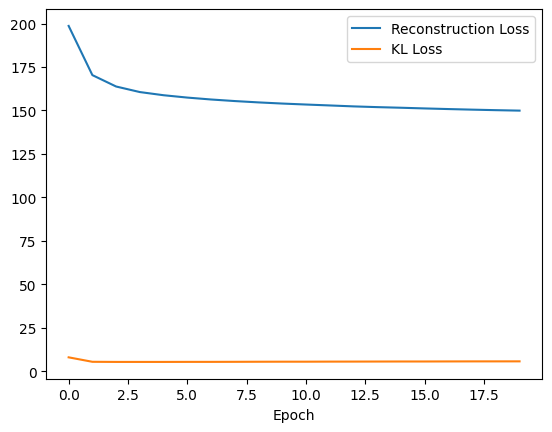

In [5]:
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

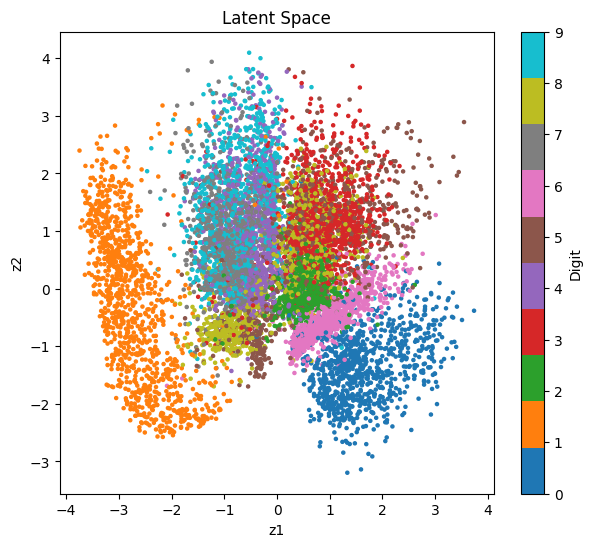

In [6]:
model.eval()
points, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(x.size(0), -1).to(device)
        mu, _ = model.encode(x)
        points.append(mu.cpu().numpy())
        labels.append(y.numpy())

points = np.concatenate(points)
labels = np.concatenate(labels)

plt.figure(figsize=(7, 6))
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap="tab10", s=5)
plt.colorbar(label="Digit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space")
plt.show()

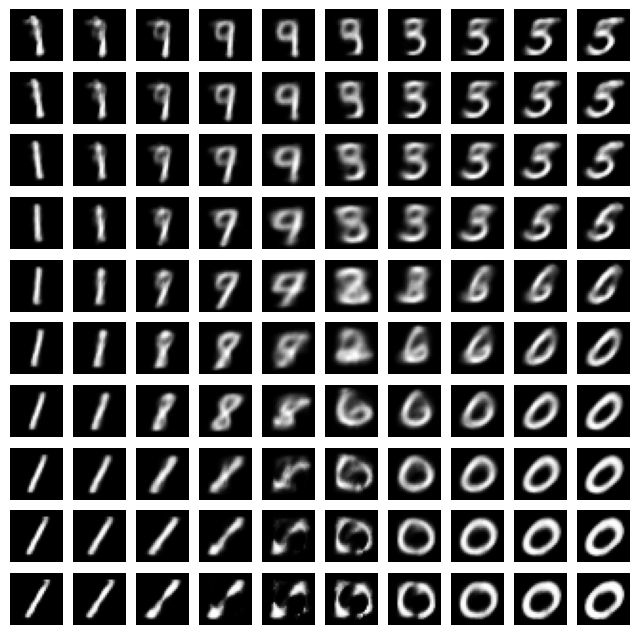

In [7]:
n = 10
grid = np.linspace(-3, 3, n)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
with torch.no_grad():
    for i, y in enumerate(reversed(grid)):
        for j, x in enumerate(grid):
            z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
            img = model.decode(z).cpu().numpy().reshape(28, 28)
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")
plt.show()

Part A


In [8]:
# ASSIGNMENT 9 - PART A
# Compression

original_size = 784
latent_dimension = 2

compression_ratio = original_size / latent_dimension

print("Original MNIST image size:", original_size)
print("Latent representation size:", latent_dimension)
print("Compression Ratio:", compression_ratio, ":1")

Original MNIST image size: 784
Latent representation size: 2
Compression Ratio: 392.0 :1


Part B

In [9]:
# ASSIGNMENT 9 - PART B
# Reconstruction of 10 test images

model.eval()

# Get 10 test images
images, labels = next(iter(test_loader))
images = images[:10].view(10, 784).to(device)

with torch.no_grad():
    reconstructed, mu, logvar = model(images)

# Calculate MSE
mse_values = []

for i in range(10):
    mse = F.mse_loss(reconstructed[i], images[i]).item()
    mse_values.append(mse)

print("MSE for each image:")

for i, mse in enumerate(mse_values):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage MSE: {np.mean(mse_values):.6f}")

MSE for each image:
Image 1: 0.030173
Image 2: 0.071157
Image 3: 0.006239
Image 4: 0.036038
Image 5: 0.039317
Image 6: 0.006874
Image 7: 0.055864
Image 8: 0.055962
Image 9: 0.077321
Image 10: 0.030172

Average MSE: 0.040912


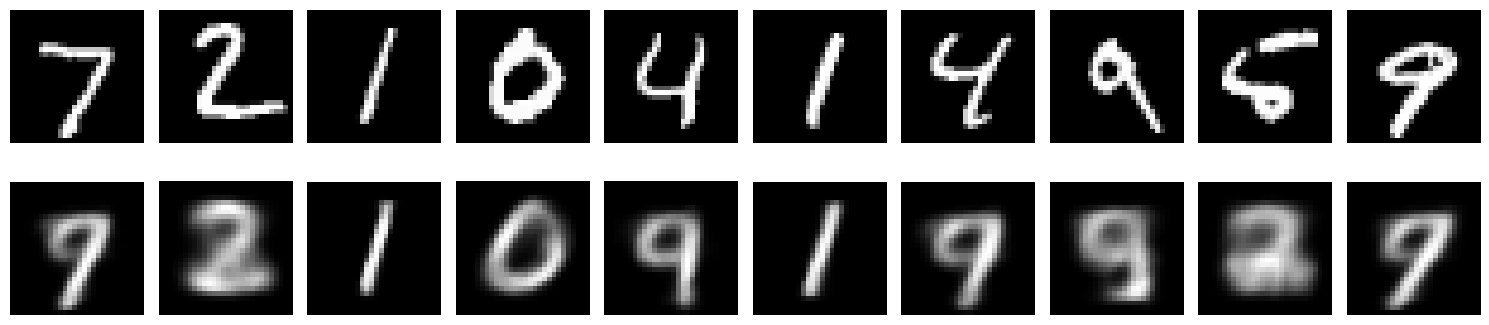

In [10]:
# Original vs Reconstructed Images

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):

    # Original image
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Reconstructed image
    axes[1, i].imshow(
        reconstructed[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

Part C — Denoising

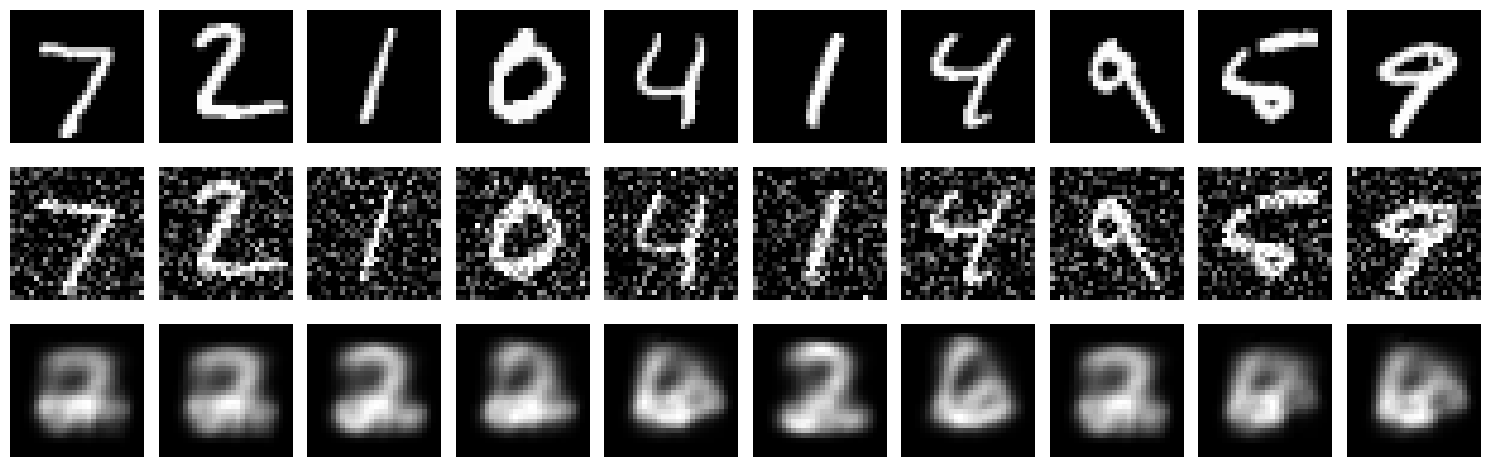

In [11]:


# Original clean images
clean_images = images.clone()

# Add Gaussian noise
noise_factor = 0.3
noise = torch.randn_like(clean_images) * noise_factor

noisy_images = clean_images + noise

# Keep pixel values between 0 and 1
noisy_images = torch.clamp(noisy_images, 0, 1)

# Pass noisy images through VAE
model.eval()

with torch.no_grad():
    denoised_images, _, _ = model(noisy_images)

# Display Original, Noisy and Denoised images
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for i in range(10):

    # Original
    axes[0, i].imshow(
        clean_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        noisy_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Noisy")
axes[2, 0].set_ylabel("Denoised")

plt.tight_layout()
plt.show()

In [12]:
# Denoising MSE

denoising_mse = []

for i in range(10):
    mse = F.mse_loss(
        denoised_images[i],
        clean_images[i]
    ).item()

    denoising_mse.append(mse)

print("Denoising MSE for each image:")

for i, mse in enumerate(denoising_mse):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage Denoising MSE: {np.mean(denoising_mse):.6f}")

Denoising MSE for each image:
Image 1: 0.068773
Image 2: 0.094477
Image 3: 0.057174
Image 4: 0.085084
Image 5: 0.054515
Image 6: 0.061348
Image 7: 0.082207
Image 8: 0.070627
Image 9: 0.080807
Image 10: 0.072733

Average Denoising MSE: 0.072774


Part D — Latent Dimension 16

In [13]:
# ASSIGNMENT 9 - PART D
# VAE with different latent dimensions

class VAE_DifferentLatent(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.latent_dim = latent_dim

        self.fc1 = nn.Linear(784, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)

        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)

        return self.decode(z), mu, logvar

In [14]:
# Train VAE with latent dimension = 16

latent_dim = 16

model_16 = VAE_DifferentLatent(latent_dim).to(device)
optimizer_16 = torch.optim.Adam(model_16.parameters(), lr=1e-3)

for epoch in range(20):

    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:

        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model_16(x)

        recon_loss = F.binary_cross_entropy(
            recon, x, reduction="sum"
        )

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu**2 - logvar.exp()
        )

        loss = recon_loss + kl_loss

        optimizer_16.zero_grad()
        loss.backward()
        optimizer_16.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"Recon Loss = {total_recon / len(train_data):.2f}, "
        f"KL Loss = {total_kl / len(train_data):.2f}"
    )

Epoch 1: Recon Loss = 177.07, KL Loss = 14.17
Epoch 2: Recon Loss = 117.57, KL Loss = 18.66
Epoch 3: Recon Loss = 106.05, KL Loss = 20.03
Epoch 4: Recon Loss = 99.85, KL Loss = 21.02
Epoch 5: Recon Loss = 96.50, KL Loss = 21.54
Epoch 6: Recon Loss = 94.36, KL Loss = 21.86
Epoch 7: Recon Loss = 92.86, KL Loss = 22.06
Epoch 8: Recon Loss = 91.68, KL Loss = 22.19
Epoch 9: Recon Loss = 90.80, KL Loss = 22.35
Epoch 10: Recon Loss = 90.06, KL Loss = 22.44
Epoch 11: Recon Loss = 89.47, KL Loss = 22.55
Epoch 12: Recon Loss = 88.94, KL Loss = 22.63
Epoch 13: Recon Loss = 88.44, KL Loss = 22.68
Epoch 14: Recon Loss = 88.08, KL Loss = 22.77
Epoch 15: Recon Loss = 87.77, KL Loss = 22.80
Epoch 16: Recon Loss = 87.43, KL Loss = 22.83
Epoch 17: Recon Loss = 87.17, KL Loss = 22.86
Epoch 18: Recon Loss = 86.91, KL Loss = 22.89
Epoch 19: Recon Loss = 86.70, KL Loss = 22.91
Epoch 20: Recon Loss = 86.52, KL Loss = 22.98


In [15]:
# Latent Dimension 16 - Reconstruction and MSE

model_16.eval()

with torch.no_grad():
    reconstructed_16, mu_16, logvar_16 = model_16(images)

mse_16 = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed_16[i],
        images[i]
    ).item()
    mse_16.append(mse)

print("Latent Dimension:", 16)
print("Compression Ratio:", 784 / 16, ":1")

print("\nMSE for each image:")

for i, mse in enumerate(mse_16):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage Reconstruction MSE: {np.mean(mse_16):.6f}")

Latent Dimension: 16
Compression Ratio: 49.0 :1

MSE for each image:
Image 1: 0.009801
Image 2: 0.018329
Image 3: 0.003786
Image 4: 0.012297
Image 5: 0.019491
Image 6: 0.003554
Image 7: 0.022787
Image 8: 0.021871
Image 9: 0.033517
Image 10: 0.014167

Average Reconstruction MSE: 0.015960


In [17]:
# Train VAE with latent dimension = 32

latent_dim = 32

model_32 = VAE_DifferentLatent(latent_dim).to(device)
optimizer_32 = torch.optim.Adam(model_32.parameters(), lr=1e-3)

for epoch in range(20):

    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:

        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model_32(x)

        recon_loss = F.binary_cross_entropy(
            recon, x, reduction="sum"
        )

        kl_loss = -0.5 * torch.sum(
            1 + logvar - mu**2 - logvar.exp()
        )

        loss = recon_loss + kl_loss

        optimizer_32.zero_grad()
        loss.backward()
        optimizer_32.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"Recon Loss = {total_recon / len(train_data):.2f}, "
        f"KL Loss = {total_kl / len(train_data):.2f}"
    )

Epoch 1: Recon Loss = 177.53, KL Loss = 14.51
Epoch 2: Recon Loss = 121.02, KL Loss = 19.17
Epoch 3: Recon Loss = 106.98, KL Loss = 21.11
Epoch 4: Recon Loss = 99.81, KL Loss = 22.18
Epoch 5: Recon Loss = 95.41, KL Loss = 22.94
Epoch 6: Recon Loss = 92.51, KL Loss = 23.54
Epoch 7: Recon Loss = 90.48, KL Loss = 23.96
Epoch 8: Recon Loss = 89.01, KL Loss = 24.29
Epoch 9: Recon Loss = 87.96, KL Loss = 24.54
Epoch 10: Recon Loss = 87.09, KL Loss = 24.69
Epoch 11: Recon Loss = 86.44, KL Loss = 24.85
Epoch 12: Recon Loss = 85.86, KL Loss = 24.94
Epoch 13: Recon Loss = 85.37, KL Loss = 25.04
Epoch 14: Recon Loss = 84.96, KL Loss = 25.13
Epoch 15: Recon Loss = 84.62, KL Loss = 25.22
Epoch 16: Recon Loss = 84.30, KL Loss = 25.27
Epoch 17: Recon Loss = 84.03, KL Loss = 25.31
Epoch 18: Recon Loss = 83.81, KL Loss = 25.34
Epoch 19: Recon Loss = 83.57, KL Loss = 25.41
Epoch 20: Recon Loss = 83.40, KL Loss = 25.43


In [18]:
# Latent Dimension 32 - Reconstruction and MSE

model_32.eval()

with torch.no_grad():
    reconstructed_32, mu_32, logvar_32 = model_32(images)

mse_32 = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed_32[i],
        images[i]
    ).item()
    mse_32.append(mse)

print("Latent Dimension:", 32)
print("Compression Ratio:", 784 / 32, ":1")

print("\nMSE for each image:")

for i, mse in enumerate(mse_32):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage Reconstruction MSE: {np.mean(mse_32):.6f}")


Latent Dimension: 32
Compression Ratio: 24.5 :1

MSE for each image:
Image 1: 0.005735
Image 2: 0.016182
Image 3: 0.005001
Image 4: 0.012114
Image 5: 0.017556
Image 6: 0.005428
Image 7: 0.026317
Image 8: 0.024377
Image 9: 0.021871
Image 10: 0.012691

Average Reconstruction MSE: 0.014727


In [19]:
# Latent Dimension 32 - Reconstruction and MSE

model_32.eval()

with torch.no_grad():
    reconstructed_32, mu_32, logvar_32 = model_32(images)

mse_32 = []

for i in range(10):
    mse = F.mse_loss(
        reconstructed_32[i],
        images[i]
    ).item()
    mse_32.append(mse)

print("Latent Dimension:", 32)
print("Compression Ratio:", 784 / 32, ":1")

print("\nMSE for each image:")

for i, mse in enumerate(mse_32):
    print(f"Image {i+1}: {mse:.6f}")

print(f"\nAverage Reconstruction MSE: {np.mean(mse_32):.6f}")

Latent Dimension: 32
Compression Ratio: 24.5 :1

MSE for each image:
Image 1: 0.007411
Image 2: 0.015968
Image 3: 0.005660
Image 4: 0.011029
Image 5: 0.012804
Image 6: 0.003767
Image 7: 0.019365
Image 8: 0.025829
Image 9: 0.022702
Image 10: 0.013550

Average Reconstruction MSE: 0.013808


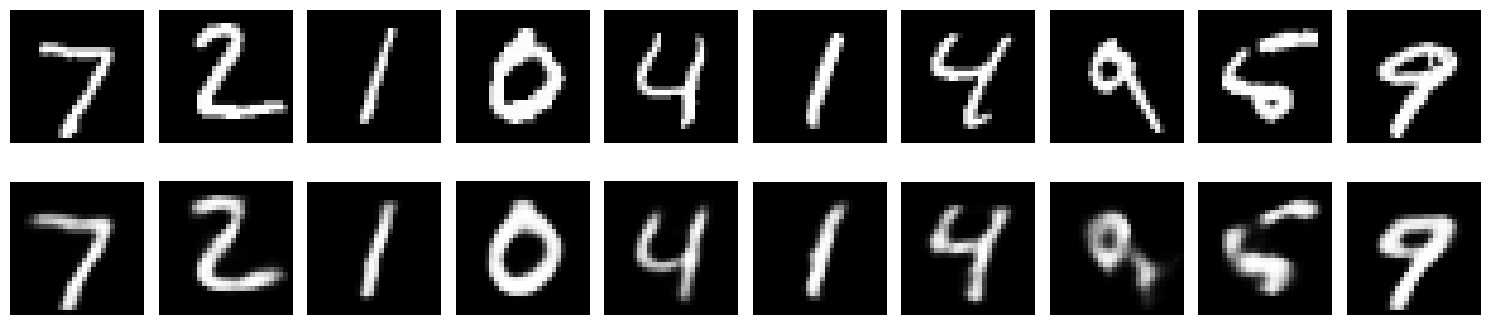

In [20]:
# Original vs Latent-32 Reconstruction

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axes[0, i].imshow(
        images[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        reconstructed_32[i].cpu().numpy().reshape(28, 28),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Latent 32")

plt.tight_layout()
plt.show()

# 1. Comparison Images

### Original vs Reconstructed Images

The original MNIST test images were compared with their reconstructed images using different latent dimensions.

- Latent Dimension 2 produced more blurry reconstructions.
- Latent Dimension 16 produced better reconstruction quality.
- Latent Dimension 32 produced the clearest reconstruction among the three.

### Original vs Noisy vs Denoised Images

Gaussian noise was added to the original test images. The noisy images were then passed through the trained VAE for denoising.

The VAE reduced the noise and produced recognizable digit images, although some blurring was observed.

| Latent Dimension | Compression Ratio | Average Reconstruction MSE | Quality |
|---:|---:|---:|---|
| **2** | **392:1** | **0.040912** | More blurry |
| **16** | **49:1** | **0.015960** | Better |
| **32** | **24.5:1** | **0.014727** | Best |

# 3. Observations

1. The original MNIST image contains 784 pixel values.

2. With a latent dimension of 2, the compression ratio was 392:1. However, the reconstructed images were relatively blurry and the average reconstruction MSE was 0.040912.

3. Increasing the latent dimension to 16 reduced the reconstruction MSE to 0.015960 and improved the reconstruction quality. The compression ratio was 49:1.

4. With a latent dimension of 32, the reconstruction MSE was 0.014727 and the reconstructed images were clearer. The compression ratio was 24.5:1.

5. Adding Gaussian noise affected the input images, but the VAE was able to reduce the noise and reconstruct recognizable digit images.

6. Increasing the latent dimension generally improved reconstruction quality, but it reduced the amount of compression.

# 4. Conclusion

The experiment demonstrated the use of a Variational Autoencoder (VAE) for image compression, reconstruction, and denoising.

A latent dimension of 2 provided the highest compression ratio of 392:1, but produced lower reconstruction quality. Increasing the latent dimension to 16 and 32 improved the reconstruction quality and reduced the reconstruction error.

Among the tested latent dimensions, 32 produced the lowest recorded reconstruction MSE of 0.014727. The denoising experiment also showed that the VAE can reduce Gaussian noise and reconstruct recognizable images.

Therefore, a larger latent dimension provides better reconstruction quality, while a smaller latent dimension provides higher compression.